In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.read_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/product_events.csv")

df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,signup_date,...,app_version,experiment_group,session_id,session_date,recommendation_seen,recommendation_clicked,restaurants_viewed,cart_created,order_completed,coupon_used
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,2023-12-19 07:40:22,...,4.8.1,Variant,S100000,2024-01-26 16:25:10,1,0,4,1,1,1
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,2023-12-25 16:13:39,...,4.9.0,Control,S100001,2024-01-26 19:11:24,1,0,1,0,1,1
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,2023-09-13 08:16:28,...,4.8.1,Control,S100002,2024-01-28 06:32:10,1,1,5,1,1,0
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,2023-09-14 19:37:14,...,4.9.0,Control,S100003,2024-01-20 14:12:23,1,0,1,0,1,1
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,2023-10-25 16:22:31,...,4.9.0,Variant,S100004,2024-01-02 06:37:48,1,1,8,1,1,0


### Step 6.2 — Create a User Base
We only need one row per customer.

In [4]:
users = df[
            [
             'customer_id',
             'signup_date',
             'experiment_group',
             'city',
             'device_type',
             'acquisition_channel'
            ]
          ].drop_duplicates()

users.head()

,customer_id,signup_date,experiment_group,city,device_type,acquisition_channel
0,337525,2023-12-19 07:40:22,Variant,Hyderabad,Android,Referral
1,358141,2023-12-25 16:13:39,Control,Bangalore,Android,Organic
2,66393,2023-09-13 08:16:28,Control,Hyderabad,Android,Facebook
3,106968,2023-09-14 19:37:14,Control,Bangalore,Android,Organic
4,76942,2023-10-25 16:22:31,Variant,Hyderabad,Android,Organic


### Step 6.3 — Convert Dates

In [5]:
users['signup_date'] = pd.to_datetime(users['signup_date'])

### Step 6.4 — Generate Repeat Sessions
Now we'll create realistic user behavior.
Each customer will have

1

↓

3

↓

5

↓

8 sessions depending on engagement.
Variant users will return slightly more often.

In [6]:
sessions = []

for _, row in users.iterrows():

    customer = row['customer_id']

    signup = row['signup_date']

    group = row['experiment_group']

    if group == "Variant":

        n_sessions = np.random.randint(3,8)

    else:

        n_sessions = np.random.randint(2,6)

    session_dates = sorted(

        signup +

        pd.to_timedelta(

            np.random.randint(0,60,n_sessions),

            unit='D'

        )

    )

    for date in session_dates:

        sessions.append({

            "customer_id":customer,

            "session_date":date,

            "experiment_group":group,

            "city":row["city"],

            "device_type":row["device_type"],

            "acquisition_channel":row["acquisition_channel"]

        })

sessions = pd.DataFrame(sessions)

sessions.head()

,customer_id,session_date,experiment_group,city,device_type,acquisition_channel
0,337525,2023-12-26 07:40:22,Variant,Hyderabad,Android,Referral
1,337525,2024-01-02 07:40:22,Variant,Hyderabad,Android,Referral
2,337525,2024-01-08 07:40:22,Variant,Hyderabad,Android,Referral
3,337525,2024-01-16 07:40:22,Variant,Hyderabad,Android,Referral
4,337525,2024-01-26 07:40:22,Variant,Hyderabad,Android,Referral


In [7]:
sessions.head(10)

,customer_id,session_date,experiment_group,city,device_type,acquisition_channel
0,337525,2023-12-26 07:40:22,Variant,Hyderabad,Android,Referral
1,337525,2024-01-02 07:40:22,Variant,Hyderabad,Android,Referral
2,337525,2024-01-08 07:40:22,Variant,Hyderabad,Android,Referral
3,337525,2024-01-16 07:40:22,Variant,Hyderabad,Android,Referral
4,337525,2024-01-26 07:40:22,Variant,Hyderabad,Android,Referral
5,337525,2024-01-30 07:40:22,Variant,Hyderabad,Android,Referral
6,358141,2024-01-04 16:13:39,Control,Bangalore,Android,Organic
7,358141,2024-01-12 16:13:39,Control,Bangalore,Android,Organic
8,358141,2024-01-16 16:13:39,Control,Bangalore,Android,Organic
9,66393,2023-10-06 08:16:28,Control,Hyderabad,Android,Facebook


### Step 6.5 — Save Session Data

In [8]:
sessions.to_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/user_sessions.csv", index=False)

In [9]:
sessions.shape

(5083, 6)

In [10]:
sessions.groupby('customer_id').size().describe()

count    1200.000000
mean        4.235833
std         1.438265
min         2.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
dtype: float64

### Step 6.6 – Build Cohort Analysis

In [11]:
import pandas as pd
import numpy as np

sessions = pd.read_csv("/Users/ajaymundari/Downloads/Project/FoodHub/Data/Processed/user_sessions.csv")

sessions.head()

,customer_id,session_date,experiment_group,city,device_type,acquisition_channel
0,337525,2023-12-26 07:40:22,Variant,Hyderabad,Android,Referral
1,337525,2024-01-02 07:40:22,Variant,Hyderabad,Android,Referral
2,337525,2024-01-08 07:40:22,Variant,Hyderabad,Android,Referral
3,337525,2024-01-16 07:40:22,Variant,Hyderabad,Android,Referral
4,337525,2024-01-26 07:40:22,Variant,Hyderabad,Android,Referral


#### Convert Date

In [12]:
sessions['session_date'] = pd.to_datetime(sessions['session_date'])

#### Create Acquisition Month

In [13]:
sessions['cohort_month'] = (
    sessions
    .groupby('customer_id')['session_date']
    .transform('min')
    .dt.to_period('M')
)

#### Create Session Month

In [14]:
sessions['session_month'] = (
    sessions['session_date']
    .dt.to_period('M')
)

#### Calculate Cohort Index
This tells us how many months after signup the session occurred.

In [15]:
sessions['cohort_index'] = (
    (sessions['session_month'].dt.year -
     sessions['cohort_month'].dt.year)*12
    +
    (sessions['session_month'].dt.month -
     sessions['cohort_month'].dt.month)
)

#### Count Active Users

In [16]:
cohort_data = (sessions.groupby(
                                ['cohort_month','cohort_index']
                                )['customer_id'].nunique().reset_index()
               )

cohort_data.head()

,cohort_month,cohort_index,customer_id
0,2023-07,0,122
1,2023-07,1,111
2,2023-07,2,49
3,2023-08,0,220
4,2023-08,1,192


#### Pivot Table

In [17]:
cohort_table = cohort_data.pivot(

index='cohort_month',

columns='cohort_index',

values='customer_id'

)

cohort_table

cohort_index,0,1,2
cohort_month,,,
2023-07,122.0,111.0,49.0
2023-08,220.0,192.0,69.0
2023-09,221.0,185.0,59.0
2023-10,182.0,158.0,56.0
2023-11,190.0,163.0,47.0
2023-12,197.0,160.0,52.0
2024-01,64.0,45.0,NaN
2024-02,4.0,NaN,NaN


#### Calculate Retention %

In [18]:
retention = cohort_table.divide(
                                cohort_table.iloc[:,0],
                                axis=0
                                )

retention

cohort_index,0,1,2
cohort_month,,,
2023-07,1.0,0.909836,0.401639
2023-08,1.0,0.872727,0.313636
2023-09,1.0,0.837104,0.266968
2023-10,1.0,0.868132,0.307692
2023-11,1.0,0.857895,0.247368
2023-12,1.0,0.812183,0.263959
2024-01,1.0,0.703125,NaN
2024-02,1.0,NaN,NaN


In [19]:
retention = retention.round(3)*100

retention

cohort_index,0,1,2
cohort_month,,,
2023-07,100.0,91.0,40.2
2023-08,100.0,87.3,31.4
2023-09,100.0,83.7,26.7
2023-10,100.0,86.8,30.8
2023-11,100.0,85.8,24.7
2023-12,100.0,81.2,26.4
2024-01,100.0,70.3,NaN
2024-02,100.0,NaN,NaN


#### Draw Heatmap

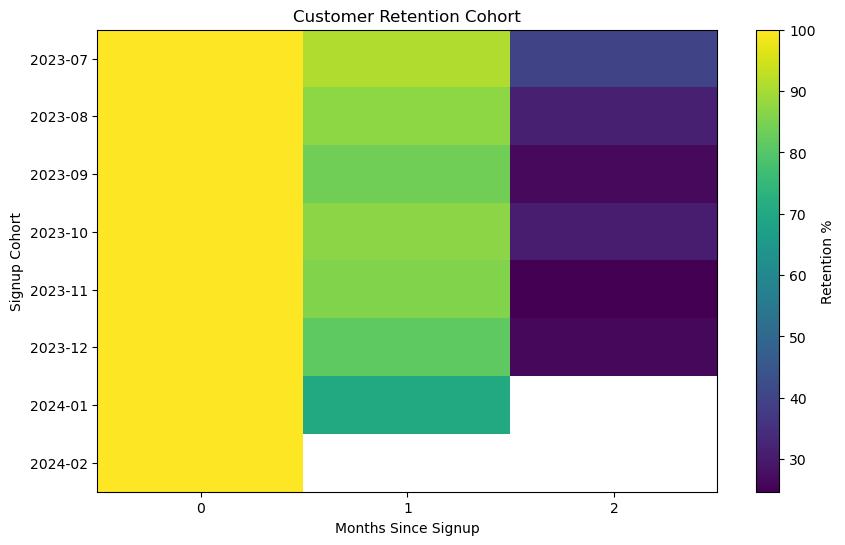

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(retention,
           aspect='auto')

plt.colorbar(label="Retention %")

plt.xticks(
range(len(retention.columns)),
retention.columns
)

plt.yticks(
range(len(retention.index)),
retention.index.astype(str)
)

plt.xlabel("Months Since Signup")

plt.ylabel("Signup Cohort")

plt.title("Customer Retention Cohort")

plt.show()